# Projeto 1: Estratégia Anti-Crise - Análise Técnica usando médias móveis em ALPA4. (+160% contra -90% do ativo)

### Desafio:

* Testar historicamente um modelo que compra e venda ALPA4 baseado no cruzamento de médias móveis. 

### Passo a passo:

   **Passo 1** - Importar as bibliotecas.
   
   **Passo 2** - Pegar os dados do Yahoo Finance.
   
   **Passo 3** - Definir as janelas das médias móveis. 
   
   **Passo 4** - Calcular as médias móveis.
   
   **Passo 5** - Calcular o retorno diário da ação.
   
   **Passo 6** - Criar os sinais de compra ou venda. 
   
   **Passo 7** - Calcular o retorno do modelo.
   
   **Passo 8** - Calcular o retorno da ação e do Ibovespa no mesmo período.

   **Passo 9** - Criar o gráfico de retornos para observar o resultado da estratégia.

   **Passo 10** - Otimizar os parâmetros pra gerar melhores resultados.

   ***
   
-------------------

# Passo 1 - Importar as bibliotecas

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
plt.style.use("dark_background")

# Passo 2 - Pegar os dados do Yahoo Finance

In [3]:
ticker = "PETR4.SA"
data = yf.download(ticker, start="2010-01-01", end="2024-09-10")

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PETR4.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


# Passo 3 - Definir as janelas das médias móveis

In [4]:
janela_rapida = 9
janela_lenta = 21

# Passo 4 - Calcular as médias móveis

In [5]:
# Calculando as médias móveis
data['Média Rápida'] = data['Adj Close'].rolling(window=janela_rapida).mean()
data['Média Lenta'] = data['Adj Close'].rolling(window=janela_lenta).mean()

# Passo 5 - Calcular o retorno diário da ação

In [6]:
data["retorno_diario"] = data["Adj Close"].pct_change()
data = data.dropna()

# Passo 6 - Criar os sinais de compra ou venda

In [7]:
# Criando a coluna 'Sinal' para marcar os pontos de compra (1) e venda (-1)
data['comprado_ou_vendido'] = 0
data['comprado_ou_vendido'] = np.where(data['Média Rápida'] > data['Média Lenta'], 1, -1)
data['comprado_ou_vendido'] = data['comprado_ou_vendido'].shift(1)

# Passo 7 - Calcular o retorno do modelo

In [8]:
data["retorno_modelo"] = data["retorno_diario"] * data["comprado_ou_vendido"]

In [9]:
data['retorno_acum_modelo'] = (1 + data['retorno_modelo']).cumprod() - 1

# Passo 8 - Calcular o retorno da ação e do Ibovespa no mesmo período

In [10]:
data['retorno_acum_acao'] = (1 + data['retorno_diario']).cumprod() - 1

In [11]:
ibov = yf.download("^BVSP", start = data.index[0], end = "2024-09-10")["Close"]

data["retorno_ibov"] = ibov.pct_change().values
data["retorno_ibov"] = (1 + data["retorno_ibov"]).cumprod() - 1 

data

IndexError: index 0 is out of bounds for axis 0 with size 0

# Passo 9 - Criar o gráfico de retornos para observar o resultado da estratégia.

KeyError: 'retorno_ibov'

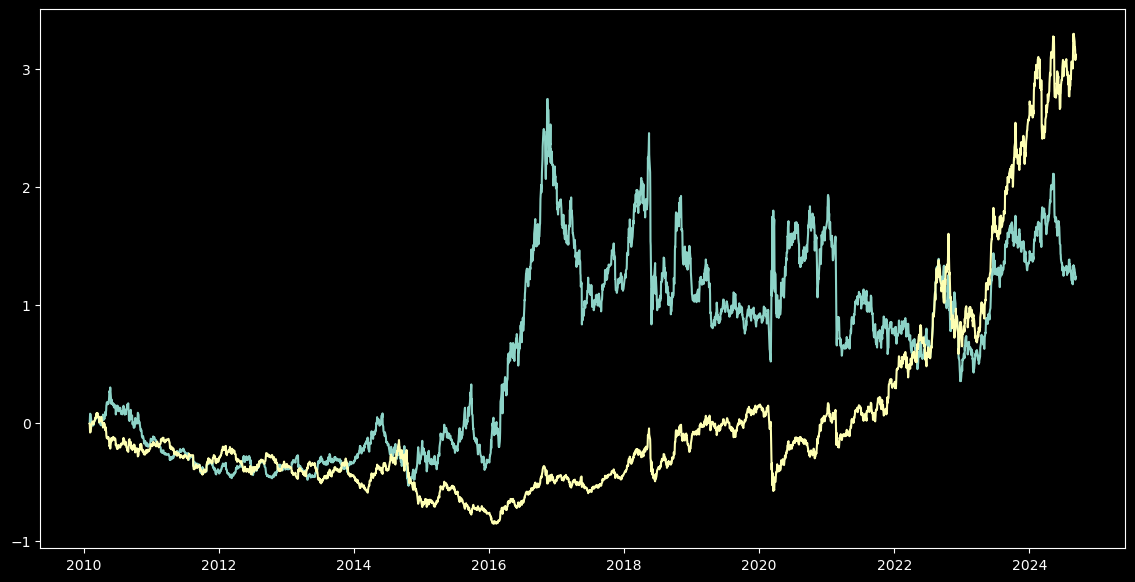

In [ ]:
# Plotando o resultado
plt.figure(figsize=(14, 7))
plt.plot(data['retorno_acum_modelo'], label='MODELO')
plt.plot(data['retorno_acum_acao'], label='STOCK')
plt.plot(data['retorno_ibov'], label='Ibovespa')
plt.title(f'Retorno Acumulado: Estratégia de Médias Móveis vs {ticker}')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(loc='best')
plt.show()

# Passo 10: Otimizar os resultados